# Numerical Differentiation & Polynomial Interpolation

برای هر رابطه دو چیز آمده است:
- **[BUILT-IN]** : دستور آمادهٔ کتابخانه‌ای (اگر وجود دارد از این استفاده کنید)
- **[MANUAL]** : پیاده‌سازی بهینهٔ دستی (وقتی دستور آماده نیست یا برای فهم)

فرم انتخابی (برداری / ماتریسی / تابعی) بر اساس بهینه بودن انتخاب شده و در هر بخش توضیح داده شده است.

In [1]:
import numpy as np
from math import factorial
from scipy.optimize import approx_fprime
from scipy.special import binom
from scipy.interpolate import KroghInterpolator

try:
    from scipy.differentiate import derivative as scipy_derivative  # SciPy >= 1.15
    _HAS_SCIPY_DERIV = True
except Exception:
    _HAS_SCIPY_DERIV = False

## 1) گرادیان تابع چندمتغیره  $f:\mathbb{R}^n\to\mathbb{R}$
$$ \frac{\partial f}{\partial x_i} \approx \frac{f(x+he_i)-f(x)}{h} $$
فرم بهینه: **برداری** با ماتریس $hI$.

In [2]:
# [BUILT-IN]
def grad_builtin(f, x, h=1e-6):
    x = np.asarray(x, dtype=float)
    return approx_fprime(x, f, h)

# [MANUAL]
def grad_manual(f, x, h=1e-6):
    x = np.asarray(x, dtype=float)
    n = x.size
    E = np.eye(n) * h
    fx = f(x)
    fp = np.array([f(x + E[i]) for i in range(n)])
    return (fp - fx) / h

## 2) مشتق اول پیشرو (forward)  $O(h)$
$$ f'(x)=\lim_{h\to0}\frac{f(x+h)-f(x)}{h}\approx\frac{f_{i+1}-f_i}{h} $$
فرم بهینه: **تابعی** (SciPy جدید با کنترل خطای خودکار).

In [3]:
# [BUILT-IN]
def deriv_fwd_builtin(f, x, h=1e-6):
    if _HAS_SCIPY_DERIV:
        return scipy_derivative(f, x).df
    return (f(x + h) - f(x)) / h

# [MANUAL]
def deriv_fwd(f, x, h=1e-5):
    return (f(x + h) - f(x)) / h

## 3) مشتق مرکزی اول  $O(h^2)$
$$ f'(x_i)\approx\frac{f_{i+1}-f_{i-1}}{2h} $$
روی آرایه: `np.gradient` (برداری)؛ روی تابع: تابعی.

In [4]:
# [BUILT-IN] روی آرایه
def dfdx_array_builtin(y, h):
    return np.gradient(y, h)

# [MANUAL] مرکزی روی تابع
def deriv_central(f, x, h=1e-5):
    return (f(x + h) - f(x - h)) / (2 * h)

## 4) عملگر تفاضل پیشرو  $\Delta,\Delta^2,\Delta^3,\dots$
$$ \Delta f_i=f_{i+1}-f_i,\quad \Delta^2 f_i=f_{i+2}-2f_{i+1}+f_i $$
این «تفاضل مرتبهٔ n» است، نه توان n. فرم بهینه: **برداری** با `np.diff`.

In [5]:
# [BUILT-IN]
def forward_diff(y, n=1):
    return np.diff(y, n=n)

# [MANUAL] Δ^n با ضرایب دوجمله‌ای علامت‌دار
def forward_diff_manual(y, n=1):
    y = np.asarray(y, dtype=float)
    k = np.arange(n + 1)
    coef = ((-1) ** (n - k)) * binom(n, k)
    m = y.size - n
    return np.array([coef @ y[i:i + n + 1] for i in range(m)])

## 5) ضریب دوجمله‌ای تعمیم‌یافته  $\binom{s}{i}=\frac{s(s-1)\cdots(s-i+1)}{i!}$
برای $s$ کسری هم درست است.

In [6]:
# [BUILT-IN]
def gen_binom_builtin(s, i):
    return binom(s, i)

# [MANUAL] حاصل‌ضرب تجمعی، بدون سرریز فاکتوریل
def gen_binom(s, i):
    num = 1.0
    for k in range(i):
        num *= (s - k)
    return num / factorial(i)

## 6) درون‌یابی نیوتن پیشرو  $P(x)$
$$ P(x)=f_0+\binom{s}{1}\Delta f_0+\binom{s}{2}\Delta^2 f_0+\cdots,\quad s=\frac{x-x_0}{h} $$
فرم بهینه: **برداری** روی جدول تفاضلات.

In [7]:
# [BUILT-IN] معادل پایدارتر
def interp_builtin(xs, ys):
    return KroghInterpolator(xs, ys)

# [MANUAL] فرمول نیوتن پیشرو، برداری‌شده
def newton_forward(x, x0, h, f_values):
    f_values = np.asarray(f_values, dtype=float)
    n = f_values.size - 1
    diffs = np.array([np.diff(f_values, k)[0] for k in range(n + 1)])
    s = (x - x0) / h
    coef = np.array([binom(s, k) for k in range(n + 1)])
    return coef @ diffs

## 7) مشتق اول از بسط نیوتن
$$ f'(x)\simeq\frac{1}{h}\Big[\Delta f_i+(s-\tfrac12)\Delta^2 f_i+\tfrac{3s^2-6s+2}{6}\Delta^3 f_i+\cdots\Big] $$
**اصلاح باگ کد اولیه:** باید $\Delta^2,\Delta^3$ (تفاضل مرتبه‌بالا) باشد، نه $(\Delta f)^2$.

In [8]:
# [MANUAL] — دستور آمادهٔ مستقیم ندارد
def f_prime_newton(f_values, i, s, h):
    f_values = np.asarray(f_values, dtype=float)
    d1 = np.diff(f_values, 1)[i]
    d2 = np.diff(f_values, 2)[i]
    d3 = np.diff(f_values, 3)[i]
    return (1 / h) * (d1 + (s - 0.5) * d2 + (3 * s**2 - 6 * s + 2) / 6 * d3)

## 8) مشتق دوم
$$ f''(x_i)\approx\frac{f_{i-1}-2f_i+f_{i+1}}{h^2}\quad O(h^2) $$

In [9]:
# [BUILT-IN] روی آرایه
def d2_array_builtin(y, h):
    return np.gradient(np.gradient(y, h), h)

# [MANUAL] استنسل مرکزی روی تابع
def deriv2_central(f, x, h=1e-4):
    return (f(x - h) - 2 * f(x) + f(x + h)) / h**2

## 9) مشتق سوم
$$ f'''(x_i)\approx\frac{f_{i+2}-2f_{i+1}+2f_{i-1}-f_{i-2}}{2h^3}\quad O(h^2) $$
دستور اسکالر مستقیم ندارد؛ استنسل مرکزی بهینه است.

In [10]:
# [MANUAL]
def deriv3_central(f, x, h=1e-3):
    return (f(x + 2*h) - 2*f(x + h) + 2*f(x - h) - f(x - 2*h)) / (2 * h**3)

## 10) عمومی: ضرایب استنسل هر مشتق و هر دقت
جایگزین همهٔ فرمول‌های بالا با یک الگوریتم واحد (حل دستگاه Vandermonde).
فرم بهینه: **ماتریسی** — یک بار حل، سپس ضرب داخلی.

In [11]:
# [BUILT-IN جایگزین قوی‌تر اگر نصب باشد]:
#   from findiff import FinDiff, coefficients
#   coefficients(deriv=2, acc=2)

# [MANUAL] ضرایب تفاضل محدود روی نقاط دلخواه (Fornberg)
def fd_coeffs(order, offsets):
    offsets = np.asarray(offsets, dtype=float)
    n = offsets.size
    A = np.vander(offsets, n, increasing=True).T
    b = np.zeros(n)
    b[order] = factorial(order)
    return np.linalg.solve(A, b)

def deriv_general(f, x, order=1, offsets=(-1, 0, 1), h=1e-4):
    c = fd_coeffs(order, offsets)
    vals = np.array([f(x + o * h) for o in offsets])
    return (c @ vals) / h**order

## 11) خطای مشتق پیشرو
$$ \frac{f_{i+1}-f_i}{h}-f'_i\simeq\frac{h}{2}f''_i=O(h) $$

In [12]:
def forward_error(f, fprime_exact, x, h=1e-3):
    approx = (f(x + h) - f(x)) / h
    return approx - fprime_exact(x)

## تست صحت با $f(x)=\sin x$

In [13]:
f  = np.sin
f1 = np.cos
f2 = lambda x: -np.sin(x)
f3 = lambda x: -np.cos(x)
x0 = 1.0

print("f'  central :", deriv_central(f, x0),  " exact:", f1(x0))
print("f'  general :", deriv_general(f, x0, 1, (-1, 0, 1)))
print("f'' central :", deriv2_central(f, x0), " exact:", f2(x0))
print("f'' general :", deriv_general(f, x0, 2, (-1, 0, 1)))
print("f'''central :", deriv3_central(f, x0), " exact:", f3(x0))
print("f''' general:", deriv_general(f, x0, 3, (-2, -1, 0, 1, 2)))

g = lambda v: v[0]**2 + 3 * v[0] * v[1] + np.sin(v[1])
print("grad manual :", grad_manual(g, [1.0, 2.0]))
print("grad builtin:", grad_builtin(g, [1.0, 2.0]))

print("C(0.5,2)    :", gen_binom(0.5, 2), " builtin:", binom(0.5, 2))

xs = np.linspace(0, 1, 5)
ys = np.sin(xs)
hh = xs[1] - xs[0]
print("newton P(0.3):", newton_forward(0.3, xs[0], hh, ys), " exact:", np.sin(0.3))

e1 = forward_error(f, f1, x0, 1e-2)
e2 = forward_error(f, f1, x0, 5e-3)
print("forward error ratio ~2:", e1 / e2)

f'  central : 0.5403023058569989  exact: 0.5403023058681398
f'  general : 0.5403023049677103
f'' central : -0.841470981782777  exact: -0.8414709848078965
f'' general : -0.841470981782777
f'''central : -0.5403021363648008  exact: -0.5403023058681398
f''' general: -0.5403455460850636
grad manual : [8.000001   2.58385271]
grad builtin: [8.000001   2.58385271]
C(0.5,2)    : -0.125  builtin: -0.125
newton P(0.3): 0.2955271848999013  exact: 0.29552020666133955
forward error ratio ~2: 2.0021255198210572


## نمودار همگرایی خطا (log-log)
شیب forward باید ~1 ($O(h)$) و central باید ~2 ($O(h^2)$) باشد.

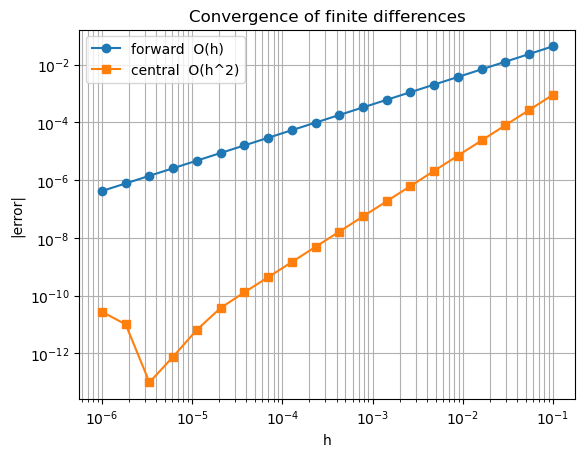

In [14]:
import matplotlib.pyplot as plt

hs = np.logspace(-1, -6, 20)
err_fwd = [abs((f(x0 + h) - f(x0)) / h - f1(x0)) for h in hs]
err_cen = [abs((f(x0 + h) - f(x0 - h)) / (2 * h) - f1(x0)) for h in hs]

plt.loglog(hs, err_fwd, 'o-', label='forward  O(h)')
plt.loglog(hs, err_cen, 's-', label='central  O(h^2)')
plt.xlabel('h'); plt.ylabel('|error|'); plt.legend(); plt.grid(True, which='both')
plt.title('Convergence of finite differences'); plt.show()